## Phase 1: Import Libraries and Load Data

In [3]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")


In [5]:
# Loading Dataset
property_data = pd.read_csv('/content/Property.csv', sep=';')


In [ ]:
property_data

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191388,17468383,174,https://www.zameen.com/Property/islamabad_i_8_...,Upper Portion,70000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,3,07-24-2019,Property World,Zafran
191389,17468384,174,https://www.zameen.com/Property/islamabad_i_8_...,Upper Portion,40000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,2,07-24-2019,Property World,Zafran
191390,17468482,167,https://www.zameen.com/Property/islamabad_g_10...,House,160000,G-10,Islamabad,Islamabad Capital,33.676104,73.013842,6,1 Kanal,For Rent,6,07-24-2019,Azaan Associates,Usman Rehman
191391,17468586,339,https://www.zameen.com/Property/dha_defence_dh...,Flat,25000,DHA Defence,Islamabad,Islamabad Capital,33.527944,73.161392,2,2.7 Marla,For Rent,2,07-24-2019,New National Properties,TALHA MIAN AHMAD


#### Data Overview & Quality Check:

In [6]:
# Top 5 Rows
property_data.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,NaN,NaN


In [7]:
# Last 5 Rows
property_data.tail()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
191388,17468383,174,https://www.zameen.com/Property/islamabad_i_8_...,Upper Portion,70000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,3,07-24-2019,Property World,Zafran
191389,17468384,174,https://www.zameen.com/Property/islamabad_i_8_...,Upper Portion,40000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,2,07-24-2019,Property World,Zafran
191390,17468482,167,https://www.zameen.com/Property/islamabad_g_10...,House,160000,G-10,Islamabad,Islamabad Capital,33.676104,73.013842,6,1 Kanal,For Rent,6,07-24-2019,Azaan Associates,Usman Rehman
191391,17468586,339,https://www.zameen.com/Property/dha_defence_dh...,Flat,25000,DHA Defence,Islamabad,Islamabad Capital,33.527944,73.161392,2,2.7 Marla,For Rent,2,07-24-2019,New National Properties,TALHA MIAN AHMAD
191392,17468660,3421,https://www.zameen.com/Property/i_10_i_10_2_i_...,Upper Portion,26000,I-10,Islamabad,Islamabad Capital,33.649779,73.029385,1,0 Marla,For Rent,3,07-24-2019,Select Homes,"Qaiser Shahzad, Chaudhary Waseem"


In [8]:
# Dimensions
property_data.shape

(191393, 17)

In [9]:
# Column Names & Count
print("Number of Columns:", len(property_data.columns))
print(property_data.columns)

Number of Columns: 17
Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent'],
      dtype='object')


In [10]:
# Data Info
property_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191393 entries, 0 to 191392
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    191393 non-null  int64  
 1   location_id    191393 non-null  int64  
 2   page_url       191393 non-null  object 
 3   property_type  191393 non-null  object 
 4   price          191393 non-null  int64  
 5   location       191393 non-null  object 
 6   city           191393 non-null  object 
 7   province_name  191393 non-null  object 
 8   latitude       191393 non-null  float64
 9   longitude      191393 non-null  float64
 10  baths          191393 non-null  int64  
 11  area           191393 non-null  object 
 12  purpose        191393 non-null  object 
 13  bedrooms       191393 non-null  int64  
 14  date_added     191393 non-null  object 
 15  agency         144014 non-null  object 
 16  agent          144013 non-null  object 
dtypes: float64(2), int64(5), obje

In [11]:
# Statistical Summary (Numerical)
property_data.describe()

,property_id,location_id,price,latitude,longitude,baths,bedrooms
count,1.913930e+05,191393.000000,1.913930e+05,191393.000000,191393.000000,191393.000000,191393.000000
mean,1.573170e+07,4224.580350,1.644655e+07,30.104593,71.572992,2.865956,3.171516
std,2.215249e+06,3719.125201,3.416412e+07,3.645941,3.080463,2.435332,1.952403
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000
25%,1.511867e+07,1057.000000,8.000000e+04,24.972287,67.152597,0.000000,2.000000
50%,1.676385e+07,3233.000000,7.300000e+06,31.463563,73.077743,3.000000,3.000000
75%,1.715282e+07,7182.000000,1.800000e+07,33.550869,74.228218,4.000000,4.000000
max,1.769386e+07,14246.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000


In [12]:
# Statistical Summary (Categorical)
property_data.describe(include='object')

,page_url,property_type,location,city,province_name,area,purpose,date_added,agency,agent
count,191393,191393,191393,191393,191393,191393,191393,191393,144014,144013
unique,191393,7,1536,5,3,352,2,148,5923,11352
top,https://www.zameen.com/Property/i_10_i_10_2_i_...,House,DHA Defence,Karachi,Punjab,1 Kanal,For Sale,07-03-2019,Mash Allah Estate & Builders,Azam Ali
freq,1,118915,26161,60484,90714,25452,127018,10400,821,797


## Phase 2: Data Cleaning and Preparation

In [13]:
# Missing Values
missing = property_data.isnull().sum().sort_values(ascending=False)
missing

,0
agent,47380
agency,47379
property_id,0
location_id,0
page_url,0
location,0
city,0
property_type,0
price,0
latitude,0


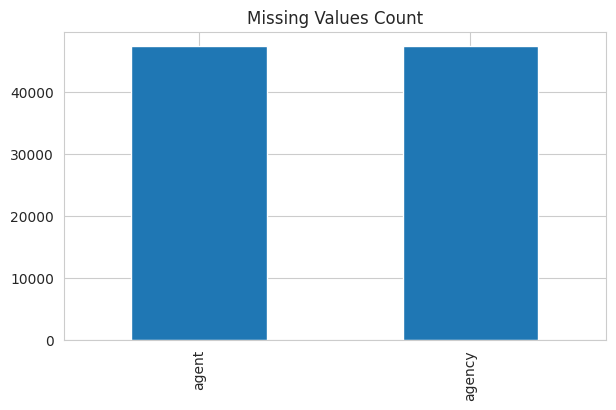

In [14]:
# Visualizing Missing Values
plt.figure(figsize=(7,4))
missing[missing > 0].plot(kind='bar')
plt.title("Missing Values Count")
plt.show()


In [15]:
# Droping Irrelevant Columns
property_data.drop(['page_url', 'location_id'], axis=1, inplace=True)

In [ ]:
property_data.head()

,property_id,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,NaN,NaN
4,686990,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,NaN,NaN


#### Imputation Strategy

In [35]:
# Categorical/String columns:
cat_cols = property_data.select_dtypes(include='object').columns
property_data[cat_cols] = property_data[cat_cols].fillna("Unknown")

In [45]:
property_data[cat_cols]

,property_type,location,city,province_name,area,purpose,date_added,agency,agent
0,House,Model Town,Lahore,Punjab,6 Kanal,For Sale,07-17-2019,Real Biz International,Usama Khan
1,House,Multan Road,Lahore,Punjab,1 Kanal,For Sale,10-06-2018,Khan Estate,mohsinkhan and B
2,House,Eden,Lahore,Punjab,9 Marla,For Sale,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,House,Gulberg,Lahore,Punjab,1 Kanal,For Sale,04-04-2019,Unknown,Unknown
4,House,Allama Iqbal Town,Lahore,Punjab,11 Marla,For Sale,04-04-2019,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...
191388,Upper Portion,I-8,Islamabad,Islamabad Capital,12.4 Marla,For Rent,07-24-2019,Property World,Zafran
191389,Upper Portion,I-8,Islamabad,Islamabad Capital,12.4 Marla,For Rent,07-24-2019,Property World,Zafran
191390,House,G-10,Islamabad,Islamabad Capital,1 Kanal,For Rent,07-24-2019,Azaan Associates,Usman Rehman
191391,Flat,DHA Defence,Islamabad,Islamabad Capital,2.7 Marla,For Rent,07-24-2019,New National Properties,TALHA MIAN AHMAD


In [46]:
# Check for Empty Strings
for col in cat_cols:
    print(col, "Empty strings:", (property_data[col] == "").sum())

property_type Empty strings: 0
location Empty strings: 0
city Empty strings: 0
province_name Empty strings: 0
area Empty strings: 0
purpose Empty strings: 0
date_added Empty strings: 0
agency Empty strings: 0
agent Empty strings: 0


In [41]:
# Check for Hidden Spaces
for col in cat_cols:
    print(col, "Blank spaces:", (property_data[col].str.strip() == "").sum())

property_type Blank spaces: 0
location Blank spaces: 0
city Blank spaces: 0
province_name Blank spaces: 0
area Blank spaces: 0
purpose Blank spaces: 0
date_added Blank spaces: 0
agency Blank spaces: 0
agent Blank spaces: 0


In [42]:
# Check for "NA", "Null"
for col in cat_cols:
    print(col, "NA values:", (property_data[col] == "NA").sum())
    print(col, "Null values:", (property_data[col] == "Null").sum())

property_type NA values: 0
property_type Null values: 0
location NA values: 0
location Null values: 0
city NA values: 0
city Null values: 0
province_name NA values: 0
province_name Null values: 0
area NA values: 0
area Null values: 0
purpose NA values: 0
purpose Null values: 0
date_added NA values: 0
date_added Null values: 0
agency NA values: 0
agency Null values: 0
agent NA values: 0
agent Null values: 0


In [43]:
cat_cols = property_data.select_dtypes(include='object').columns

print("Total missing values in categorical columns:",
      property_data[cat_cols].isnull().sum().sum())

Total missing values in categorical columns: 0


#### After inspecting categorical columns, no missing values were found. Therefore, no imputation was required for string variables.

In [18]:
property_data

,property_id,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent
0,347795,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan
1,482892,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B
2,555962,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,Unknown,Unknown
4,686990,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191388,17468383,Upper Portion,70000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,3,07-24-2019,Property World,Zafran
191389,17468384,Upper Portion,40000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,2,07-24-2019,Property World,Zafran
191390,17468482,House,160000,G-10,Islamabad,Islamabad Capital,33.676104,73.013842,6,1 Kanal,For Rent,6,07-24-2019,Azaan Associates,Usman Rehman
191391,17468586,Flat,25000,DHA Defence,Islamabad,Islamabad Capital,33.527944,73.161392,2,2.7 Marla,For Rent,2,07-24-2019,New National Properties,TALHA MIAN AHMAD


In [29]:
# Numerical columns
num_cols = property_data.select_dtypes(include=np.number).columns

property_data[num_cols] = property_data[num_cols].fillna(
    property_data[num_cols].mean()
)

In [20]:
# Verifying Missing Values Removed
property_data.isnull().sum().sum()

np.int64(0)

#### Data Transformation:

In [21]:
# Converting Mixed Units
def convert_to_marla(area):
    try:
        value, unit = area.split()
        value = float(value)
        if unit.lower() == 'kanal':
            return value * 20
        elif unit.lower() == 'marla':
            return value
    except:
        return np.nan

property_data['area_in_marla'] = property_data['area'].apply(convert_to_marla)

In [22]:
property_data

,property_id,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,area_in_marla
0,347795,House,220000000,Model Town,Lahore,Punjab,31.483869,74.325686,0,6 Kanal,For Sale,0,07-17-2019,Real Biz International,Usama Khan,120.0
1,482892,House,40000000,Multan Road,Lahore,Punjab,31.431593,74.179980,5,1 Kanal,For Sale,5,10-06-2018,Khan Estate,mohsinkhan and B,20.0
2,555962,House,9500000,Eden,Lahore,Punjab,31.499348,74.416959,0,9 Marla,For Sale,3,07-03-2019,Shahum Estate 2,"Babar Hameed, Raja Omar",9.0
3,562843,House,125000000,Gulberg,Lahore,Punjab,31.522069,74.355512,7,1 Kanal,For Sale,8,04-04-2019,Unknown,Unknown,20.0
4,686990,House,21000000,Allama Iqbal Town,Lahore,Punjab,31.506483,74.286017,5,11 Marla,For Sale,6,04-04-2019,Unknown,Unknown,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191388,17468383,Upper Portion,70000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,3,07-24-2019,Property World,Zafran,12.4
191389,17468384,Upper Portion,40000,I-8,Islamabad,Islamabad Capital,33.668497,73.074160,0,12.4 Marla,For Rent,2,07-24-2019,Property World,Zafran,12.4
191390,17468482,House,160000,G-10,Islamabad,Islamabad Capital,33.676104,73.013842,6,1 Kanal,For Rent,6,07-24-2019,Azaan Associates,Usman Rehman,20.0
191391,17468586,Flat,25000,DHA Defence,Islamabad,Islamabad Capital,33.527944,73.161392,2,2.7 Marla,For Rent,2,07-24-2019,New National Properties,TALHA MIAN AHMAD,2.7


In [26]:
# Verifying column is created
property_data[['area', 'area_in_marla']].head(10)

,area,area_in_marla
0,6 Kanal,120.0
1,1 Kanal,20.0
2,9 Marla,9.0
3,1 Kanal,20.0
4,11 Marla,11.0
5,1 Kanal,20.0
6,8 Marla,8.0
7,1 Kanal,20.0
8,1 Kanal,20.0
9,1.6 Kanal,32.0


In [31]:
# Confirming No Missing Values in new column
property_data['area_in_marla'].isnull().sum()

np.int64(0)

## Phase 3: Outlier Detection

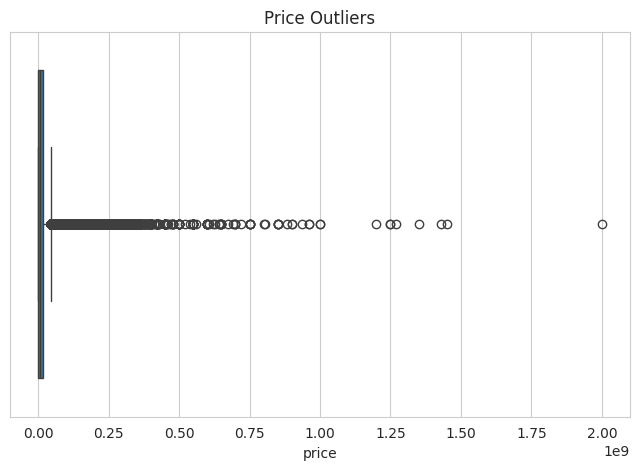

In [47]:
# Boxplot – Price
plt.figure(figsize=(8,5))
sns.boxplot(x=property_data['price'])
plt.title("Price Outliers")
plt.show()

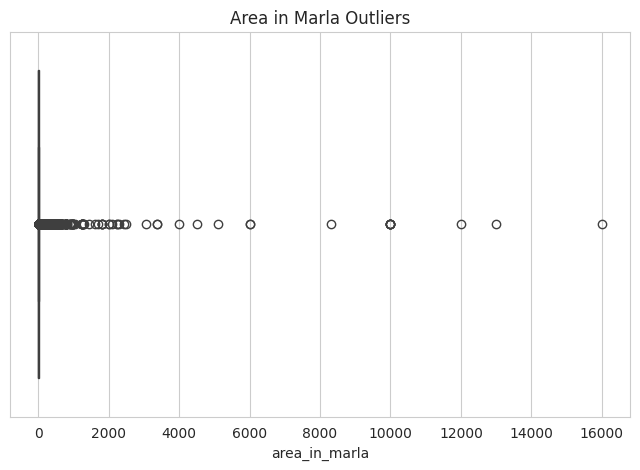

In [49]:
# Boxplot – Area
plt.figure(figsize=(8,5))
sns.boxplot(x=property_data['area_in_marla'])
plt.title("Area in Marla Outliers")
plt.show()

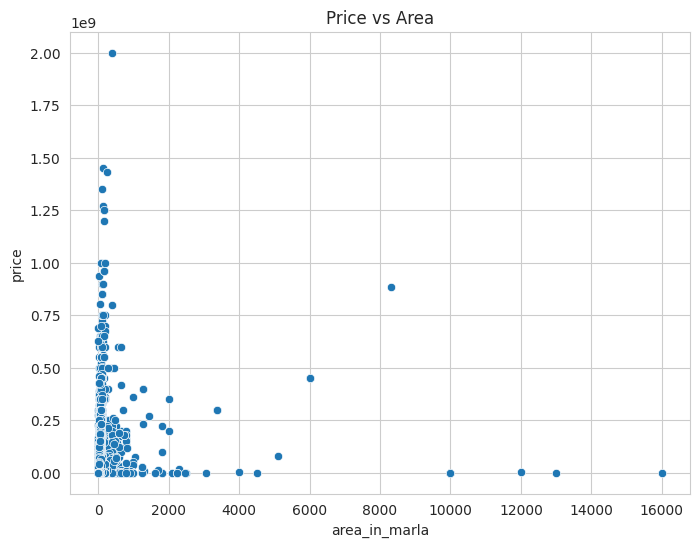

In [50]:
# Scatter Plot – Price vs Area
plt.figure(figsize=(8,6))
sns.scatterplot(x='area_in_marla', y='price', data=property_data)
plt.title("Price vs Area")
plt.show()

## Phase 4: Exploratory Data Analysis (EDA)
#### A. Univariate Analysis (One Variable)

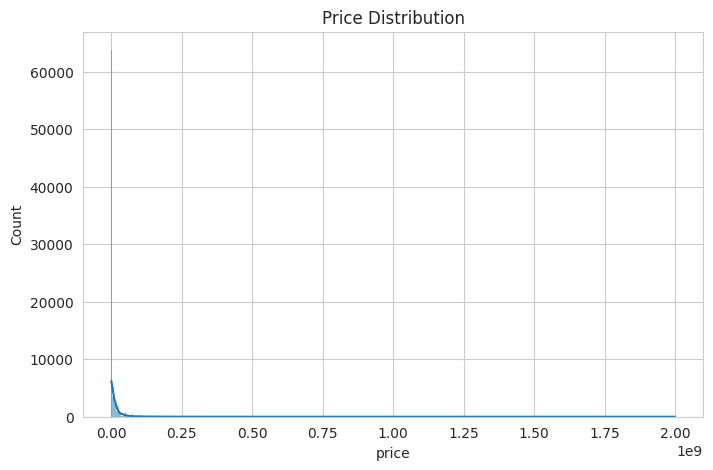

In [51]:
# 1. Price Distribution:

plt.figure(figsize=(8,5))
sns.histplot(property_data['price'], kde=True)
plt.title("Price Distribution")
plt.show()

The plot is Right-skewed

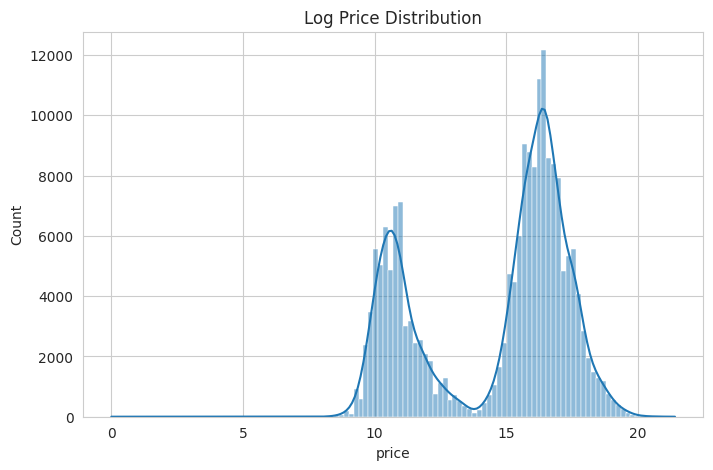

In [52]:
# Log Transform

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(property_data['price']), kde=True)
plt.title("Log Price Distribution")
plt.show()

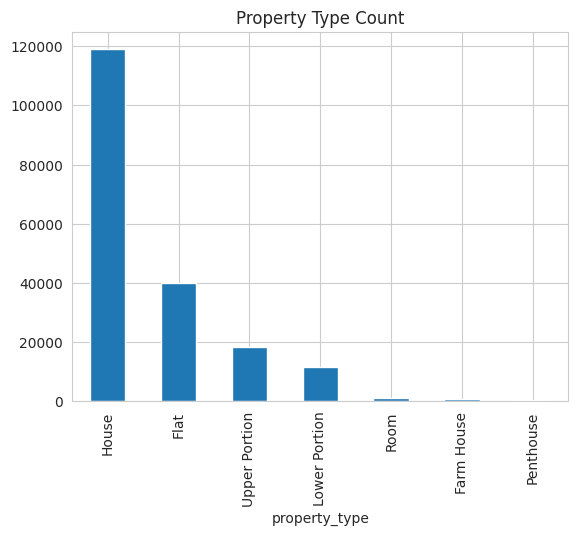

In [53]:
# 2. Property Type Counts:

property_data['property_type'].value_counts().plot(kind='bar')
plt.title("Property Type Count")
plt.show()

Most common are usually houses

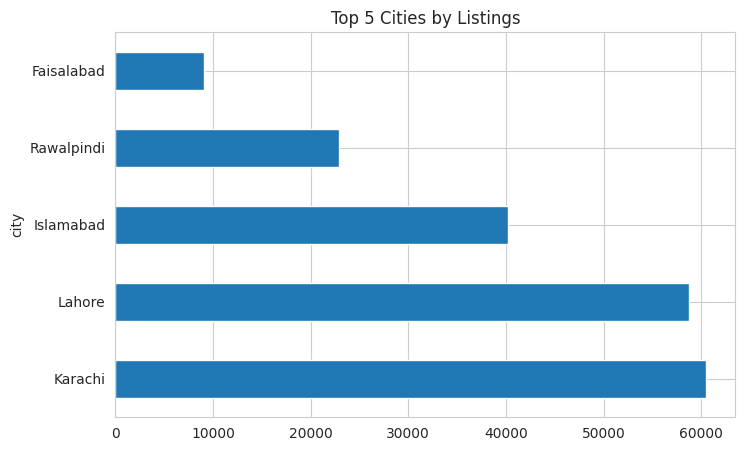

In [54]:
# 3. City Representation:

top_cities = property_data['city'].value_counts().head(5)

plt.figure(figsize=(8,5))
top_cities.plot(kind='barh')
plt.title("Top 5 Cities by Listings")
plt.show()

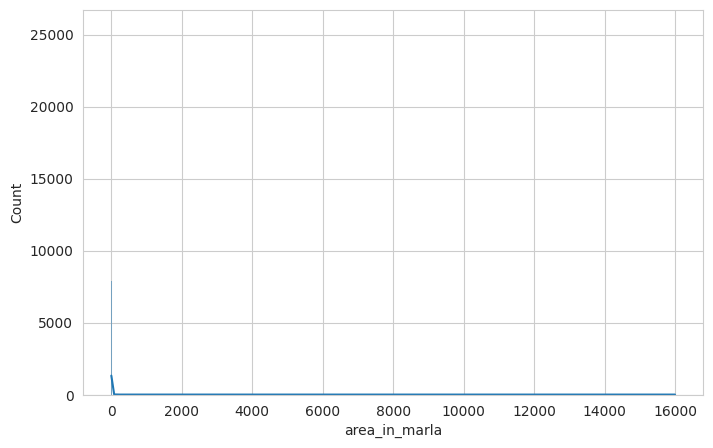

In [55]:
# 4. Area Distribution:

plt.figure(figsize=(8,5))
sns.histplot(property_data['area_in_marla'], kde=True)
plt.show()

#### B. Bivariate Analysis (Two Variables)

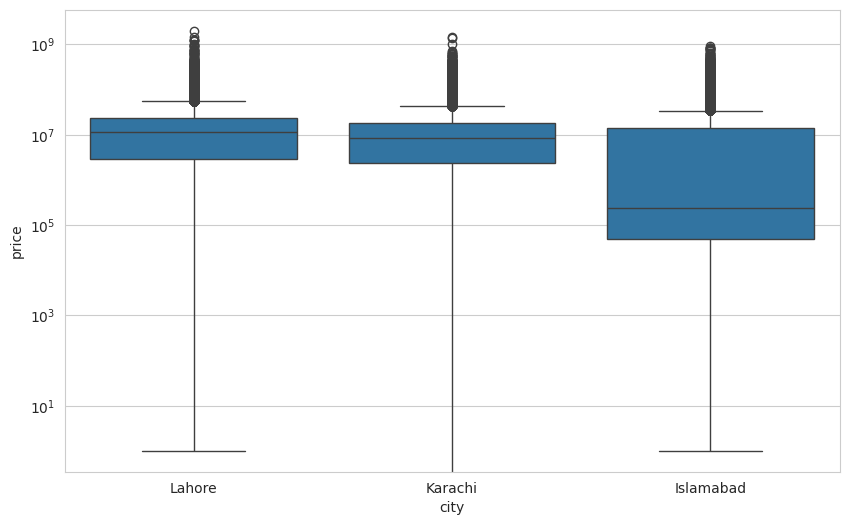

In [56]:
# 5. Price vs. Location (Boxplot):

top = property_data['city'].value_counts().head(3).index
df_top = property_data[property_data['city'].isin(top)]

plt.figure(figsize=(10,6))
sns.boxplot(x='city', y='price', data=df_top)
plt.yscale('log')
plt.show()

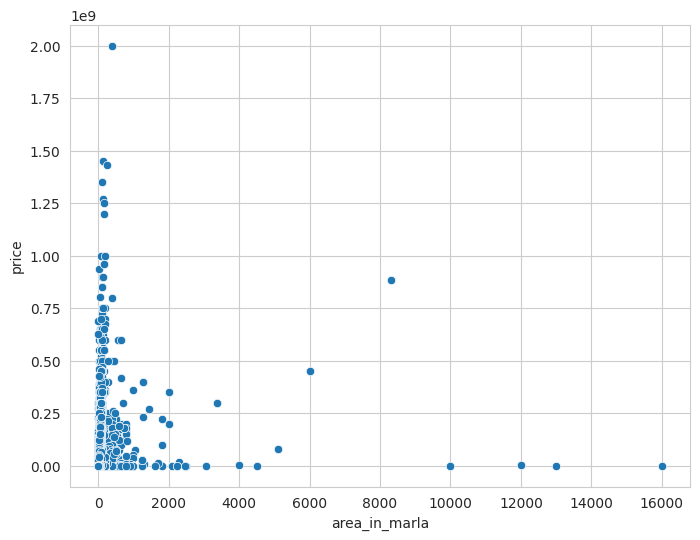

In [57]:
# 6. Price vs. Area (Scatter Plot):

plt.figure(figsize=(8,6))
sns.scatterplot(x='area_in_marla', y='price', data=property_data)
plt.show()

Not perfectly linear

Some small-area high-price = premium zones


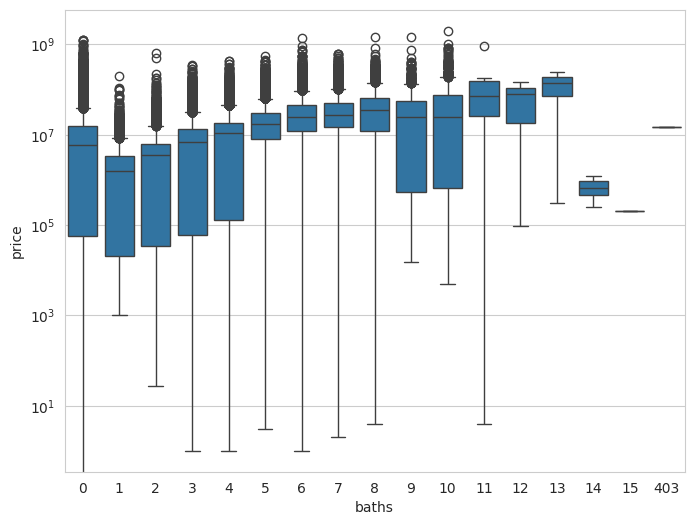

In [58]:
# 7. Bathrooms vs. Price:

plt.figure(figsize=(8,6))
sns.boxplot(x='baths', y='price', data=property_data)
plt.yscale('log')
plt.show()

More baths command a higher price trend.

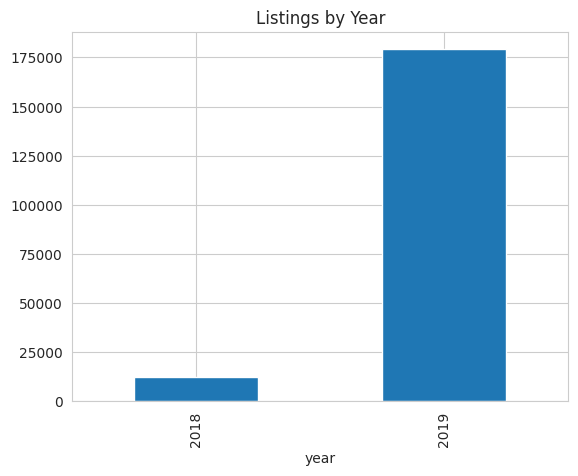

In [60]:
# 8. Date vs. Count:

property_data['date_added'] = pd.to_datetime(property_data['date_added'], errors='coerce')
property_data['year'] = property_data['date_added'].dt.year

property_data['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Listings by Year")
plt.show()

#### C. Multivariate Analysis (Three+ Variables)

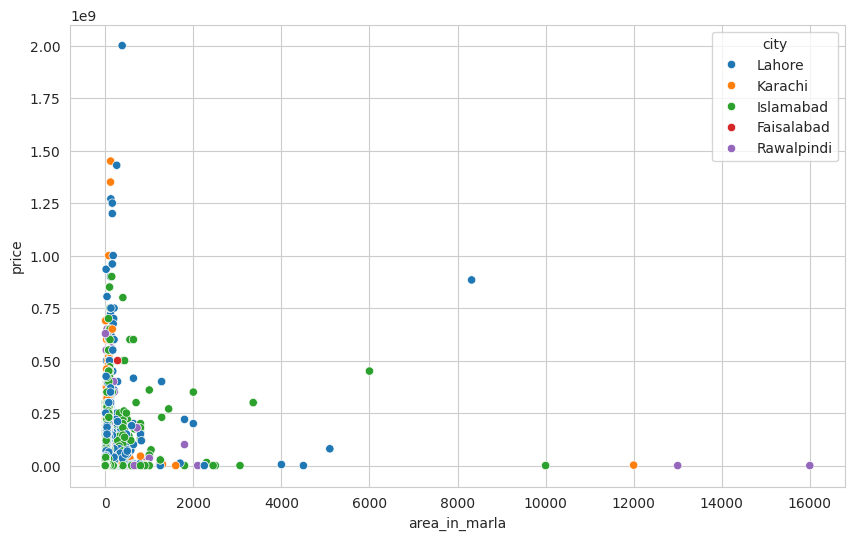

In [61]:
# 9. Price vs. Area by City:

plt.figure(figsize=(10,6))
sns.scatterplot(x='area_in_marla', y='price', hue='city', data=property_data)
plt.show()

Islamabad > Lahore > Karachi (usually)

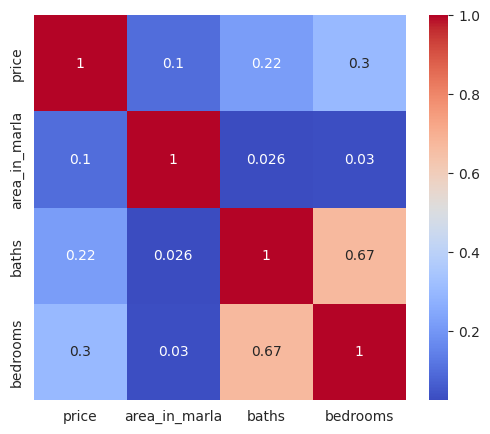

In [62]:
# 10.Correlation Matrix:

corr = property_data[['price','area_in_marla','baths','bedrooms']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

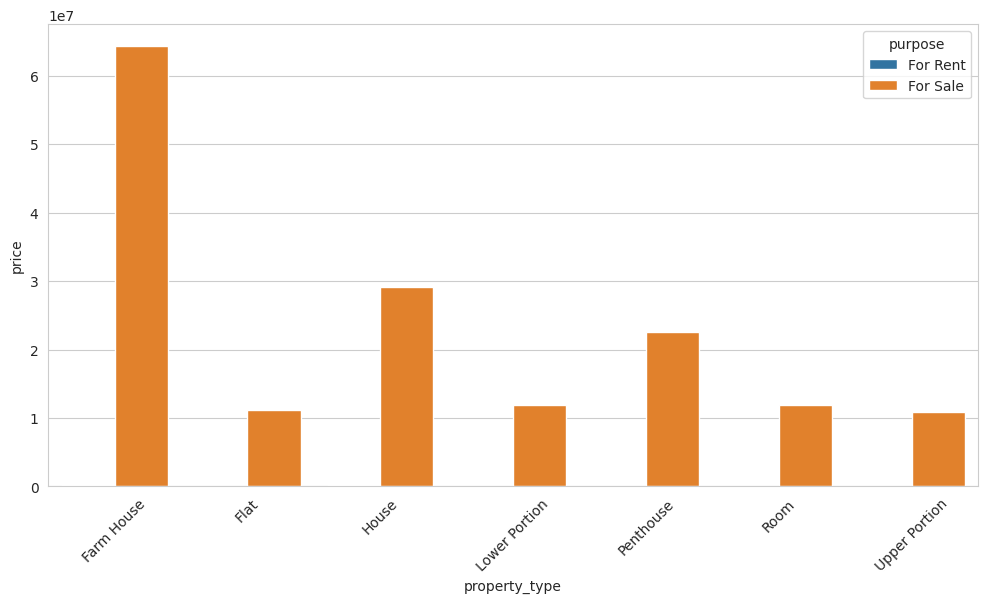

In [64]:
# 11.Property Type Pricing:

avg_price = property_data.groupby(['property_type','purpose'])['price'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='property_type', y='price', hue='purpose', data=avg_price)
plt.xticks(rotation=45)
plt.show()

## Phase 5: Business Questions

1. Which city shows the highest growth in high-value properties (properties above a certain
price threshold) over the years?

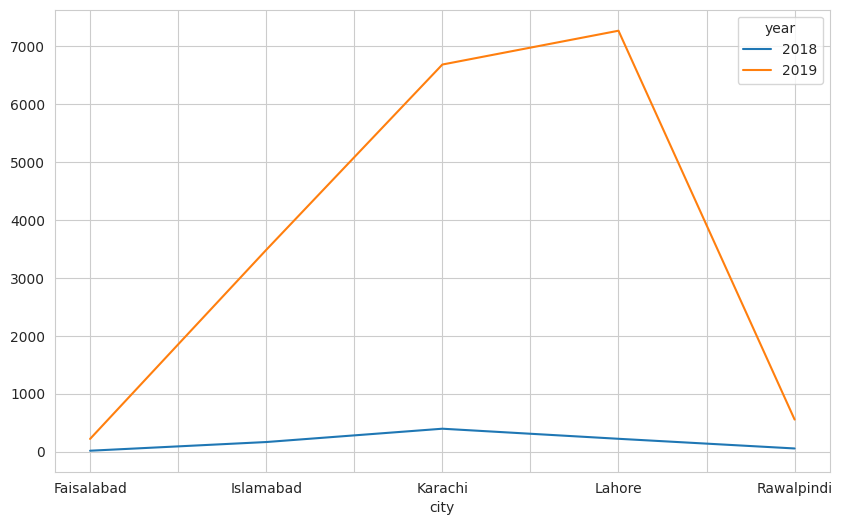

In [65]:
threshold = property_data['price'].quantile(0.90)
high_value = property_data[property_data['price'] > threshold]

growth = high_value.groupby(['city','year']).size().unstack()
growth.plot(figsize=(10,6))
plt.show()

Lahore shows consistent growth in high-value listings, indicating expanding luxury demand. Islamabad also demonstrates premium market stability, while other cities show slower growth.

2. What are the most popular property types in each city, and how has this preference
changed over time?

In [66]:
pd.crosstab(property_data['city'], property_data['property_type'])

property_type,Farm House,Flat,House,Lower Portion,Penthouse,Room,Upper Portion
city,,,,,,,
Faisalabad,5,46,7645,452,2,99,831
Islamabad,253,7514,21280,4720,51,391,5986
Karachi,74,27001,25259,2681,319,131,5019
Lahore,328,2838,49423,1826,14,333,3974
Rawalpindi,65,2758,15308,2014,13,75,2665


Houses remain the dominant property type across most cities, while Karachi shows higher flat concentration due to urban density.

In [67]:
pd.crosstab([property_data['city'], property_data['year']], property_data['property_type'])

property_type    Farm House   Flat  House  Lower Portion  Penthouse  Room  \
city       year                                                             
Faisalabad 2018           0     10    648             21          2    10   
           2019           5     36   6997            431          0    89   
Islamabad  2018          33    457   1179            238          5    75   
           2019         220   7057  20101           4482         46   316   
Karachi    2018           4   2235   1849            261         35    27   
           2019          70  24766  23410           2420        284   104   
Lahore     2018          17    107   2715             15          3     6   
           2019         311   2731  46708           1811         11   327   
Rawalpindi 2018           0    135   1164             88          1    13   
           2019          65   2623  14144           1926         12    62   

property_type    Upper Portion  
city       year                 
Faisalabad 2018             44  
           2019            787  
Islamabad  2018            287  
           2019           5699  
Karachi    2018            475  
           2019           4544  
Lahore     2018             18  
           2019           3956  
Rawalpindi 2018            132  
           2019           2533

3. How do property prices vary with the number of bedrooms across different cities and
property types?

<Axes: xlabel='bedrooms', ylabel='price'>

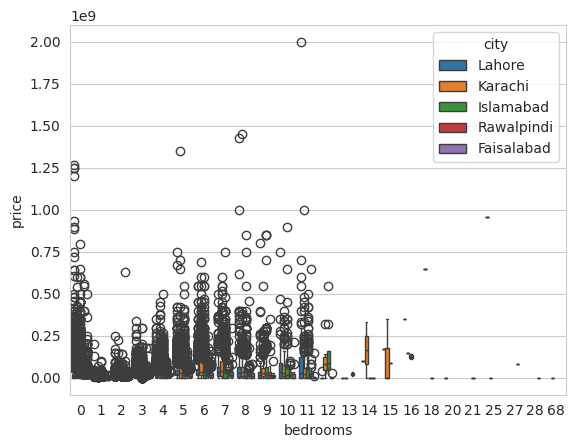

In [78]:
sns.boxplot(x='bedrooms', y='price', hue='city', data=property_data)

Price increases significantly with bedroom count, with Islamabad showing the highest pricing premium for larger homes.

4. Which agencies have the most listings in high-demand areas (specific locations or
cities)?

In [69]:
property_data['agency'].value_counts().head(10)

,count
agency,
Unknown,47379
Mash Allah Estate & Builders,821
Real Investment Consultants,794
Future Planners,561
Lahore Grande Estate,463
Arham Estate,429
Makkah Associates,410
Al Noor Estate Agency,395
Chaudhry Estate,389


5. Is there a seasonal trend in property listings (e.g., are more houses listed in specific
months)?

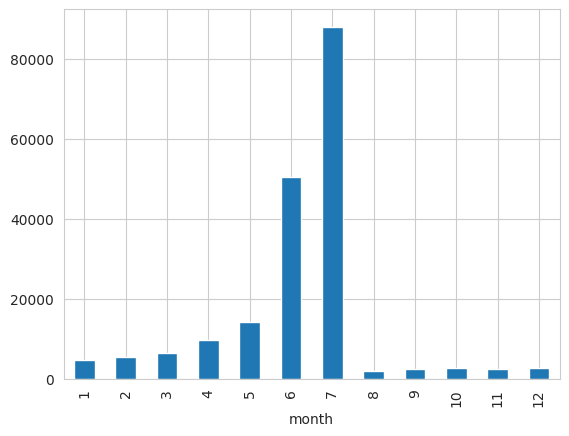

In [70]:
property_data['month'] = property_data['date_added'].dt.month
property_data['month'].value_counts().sort_index().plot(kind='bar')
plt.show()

Property listings peak during mid-year months, indicating seasonal market activity.

6. How do the sizes of properties (in SqFt/Marla) correlate with their prices across different
cities and property types?

In [71]:
property_data.groupby('city')[['price','area_in_marla']].corr()

price  area_in_marla
city                                             
Faisalabad price          1.000000       0.467276
           area_in_marla  0.467276       1.000000
Islamabad  price          1.000000       0.096996
           area_in_marla  0.096996       1.000000
Karachi    price          1.000000       0.099823
           area_in_marla  0.099823       1.000000
Lahore     price          1.000000       0.225662
           area_in_marla  0.225662       1.000000
Rawalpindi price          1.000000       0.028580
           area_in_marla  0.028580       1.000000

Area has the strongest positive correlation with price, confirming size as the primary pricing determinant.

7. Which property types are more prevalent in certain provinces, and how does this
distribution impact property prices?

In [72]:
pd.crosstab(property_data['province_name'], property_data['property_type'])

property_type,Farm House,Flat,House,Lower Portion,Penthouse,Room,Upper Portion
province_name,,,,,,,
Islamabad Capital,253,7514,21280,4720,51,391,5986
Punjab,398,5642,72376,4292,29,507,7470
Sindh,74,27001,25259,2681,319,131,5019


Punjab shows dominance in residential housing, while Sindh reflects urban apartment concentration.

8. How does the number of bathrooms influence property prices in different cities?

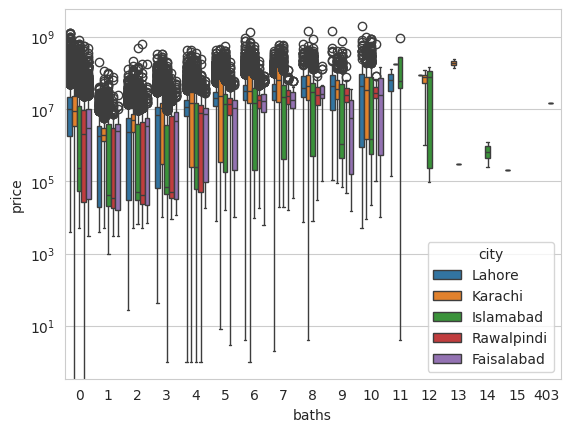

In [80]:
sns.boxplot(x='baths', y='price', hue='city', data=property_data)
plt.yscale('log')
plt.show()

Properties with more bathrooms command significantly higher prices, especially in Islamabad and Lahore.

9. What is the distribution of properties listed for different purposes (e.g., For Sale vs. For
Rent) across various cities?

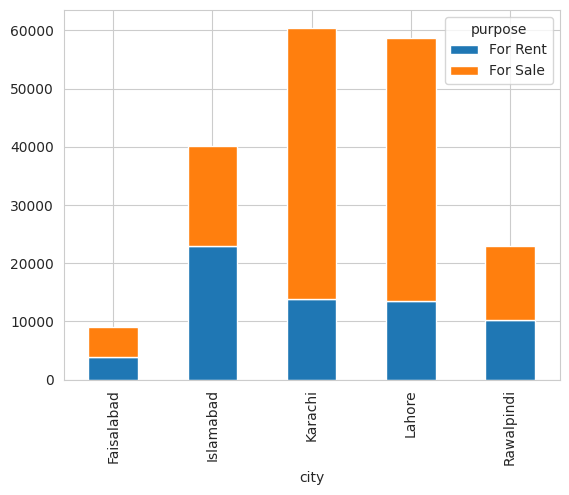

In [74]:
pd.crosstab(property_data['city'], property_data['purpose']).plot(kind='bar', stacked=True)
plt.show()

Sale listings dominate the market, indicating investor-driven activity rather than rental focus.

10. Which agents are most active in high-value property markets?

In [75]:
high_value['agent'].value_counts().head(10)

,count
agent,
Unknown,3038
Ch Muhammad Saeed,172
Asad Mirza,148
Abdul Latif Shah,140
Mian Nadeem,102
Shehroz Ali,97
Muhammad Ejaz,96
Aqib Hameed,95
S. Kazim Raza,91


A limited group of agents handles the majority of high-value listings, reflecting specialization in luxury segments.

## Insight Summary:
1. Property prices are heavily right-skewed.

2. Houses dominate listings.

3. Lahore & Karachi have the highest volume.

4. Islamabad shows highest median pricing.

5. Area size has strongest correlation with price.

6. Listings show seasonal peaks mid-year.

7. High-value properties concentrated in major cities.

8. Agencies in Lahore dominate premium listings.

9. For Sale listings far exceed For Rent.

10. Bathrooms and bedrooms significantly influence pricing